First_Aid_Knock

In [10]:
import pandas as pd # Import the pandas library for data manipulation.
df = pd.read_csv('data/medicine_details.csv') # Read the CSV file into a DataFrame for further analysis.

In [11]:
print(df.head()) # See the first few rows
print(df.info()) # Check data types and non-null counts
print(df.shape)  # Get number of rows and columns
print(df.columns) # See column names

              Medicine Name  \
0   Avastin 400mg Injection   
1  Augmentin 625 Duo Tablet   
2       Azithral 500 Tablet   
3          Ascoril LS Syrup   
4         Aciloc 150 Tablet   

                                         Composition  \
0                                Bevacizumab (400mg)   
1    Amoxycillin  (500mg) +  Clavulanic Acid (125mg)   
2                               Azithromycin (500mg)   
3  Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...   
4                                 Ranitidine (150mg)   

                                                Uses  \
0   Cancer of colon and rectum Non-small cell lun...   
1                  Treatment of Bacterial infections   
2                  Treatment of Bacterial infections   
3                      Treatment of Cough with mucus   
4  Treatment of Gastroesophageal reflux disease (...   

                                        Side_effects  \
0  Rectal bleeding Taste change Headache Noseblee...   
1  Vomiting Nausea Diarrhea

In [12]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace ('[^a-z0-9_]', '', regex=True)  # Standardize column names: remove whitespace, convert to lowercase, replace spaces with underscores, and remove special characters
print(df.columns) # Display the cleaned column names to verify the transformation.

Index(['medicine_name', 'composition', 'uses', 'side_effects', 'image_url',
       'manufacturer', 'excellent_review_', 'average_review_', 'poor_review_'],
      dtype='object')


In [13]:
print(df.isnull().sum()) # Display the count of missing values for each column in the DataFrame.

medicine_name        0
composition          0
uses                 0
side_effects         0
image_url            0
manufacturer         0
excellent_review_    0
average_review_      0
poor_review_         0
dtype: int64


In [14]:
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']: # Adjust columns as per your CSV
    if col in df.columns:
        df[col] = df[col].fillna('') # Fill with empty string

In [15]:
print(f"Number of duplicate rows before: {df.duplicated().sum()}")

Number of duplicate rows before: 84


In [16]:
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after: {df.duplicated().sum()}")
print(f"New shape after dropping duplicates: {df.shape}")

Number of duplicate rows after: 0
New shape after dropping duplicates: (11741, 9)


In [17]:
# For all relevant text columns
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

In [18]:
if 'category' in df.columns:
    print("\nTop 10 Categories:")
    print(df['category'].value_counts().head(10))

# For 'uses' column, you might want to analyze individual words
# This requires text preprocessing first (tokenization, stop word removal)

In [19]:
if 'uses' in df.columns:
    df['uses_length'] = df['uses'].apply(len)
    print("\nUses Text Length Description:")
    print(df['uses_length'].describe())


Uses Text Length Description:
count    11741.000000
mean        44.989268
std         35.974751
min          4.000000
25%         24.000000
50%         35.000000
75%         53.000000
max        483.000000
Name: uses_length, dtype: float64


In [20]:
# Example for 'uses' (requires NLTK installation: pip install nltk)
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download stopwords if not already downloaded
# nltk.download('stopwords')
# nltk.download('punkt') # For word_tokenize

stop_words = set(stopwords.words('english'))

def analyze_text_column(df_col):
    all_words = []
    for text in df_col.astype(str): # Ensure text is string
        tokens = nltk.word_tokenize(text.lower())
        filtered_words = [word for word in tokens if word.isalpha() and word not in stop_words]
        all_words.extend(filtered_words)
    return Counter(all_words).most_common(20) # Top 20 most common words

if 'uses' in df.columns:
    print("\nMost common words in 'uses' column (excluding stopwords):")
    print(analyze_text_column(df['uses']))

if 'side_effects' in df.columns:
    print("\nMost common words in 'side_effects' column (excluding stopwords):")
    print(analyze_text_column(df['side_effects']))


Most common words in 'uses' column (excluding stopwords):
[('treatment', 8286), ('infections', 1769), ('high', 1579), ('pain', 1410), ('blood', 1336), ('hypertension', 1320), ('pressure', 1236), ('disease', 1159), ('heart', 1129), ('diabetes', 1019), ('prevention', 1018), ('bacterial', 944), ('type', 923), ('mellitus', 920), ('skin', 911), ('reflux', 826), ('fungal', 754), ('attack', 664), ('due', 466), ('allergic', 451)]

Most common words in 'side_effects' column (excluding stopwords):
[('pain', 6346), ('nausea', 6170), ('headache', 5336), ('diarrhea', 4520), ('blood', 4145), ('dizziness', 4035), ('vomiting', 3473), ('increased', 2853), ('stomach', 2353), ('abdominal', 2216), ('skin', 2214), ('level', 2028), ('itching', 1994), ('site', 1792), ('rash', 1780), ('sleepiness', 1776), ('constipation', 1683), ('irritation', 1627), ('infection', 1578), ('redness', 1563)]


Graph

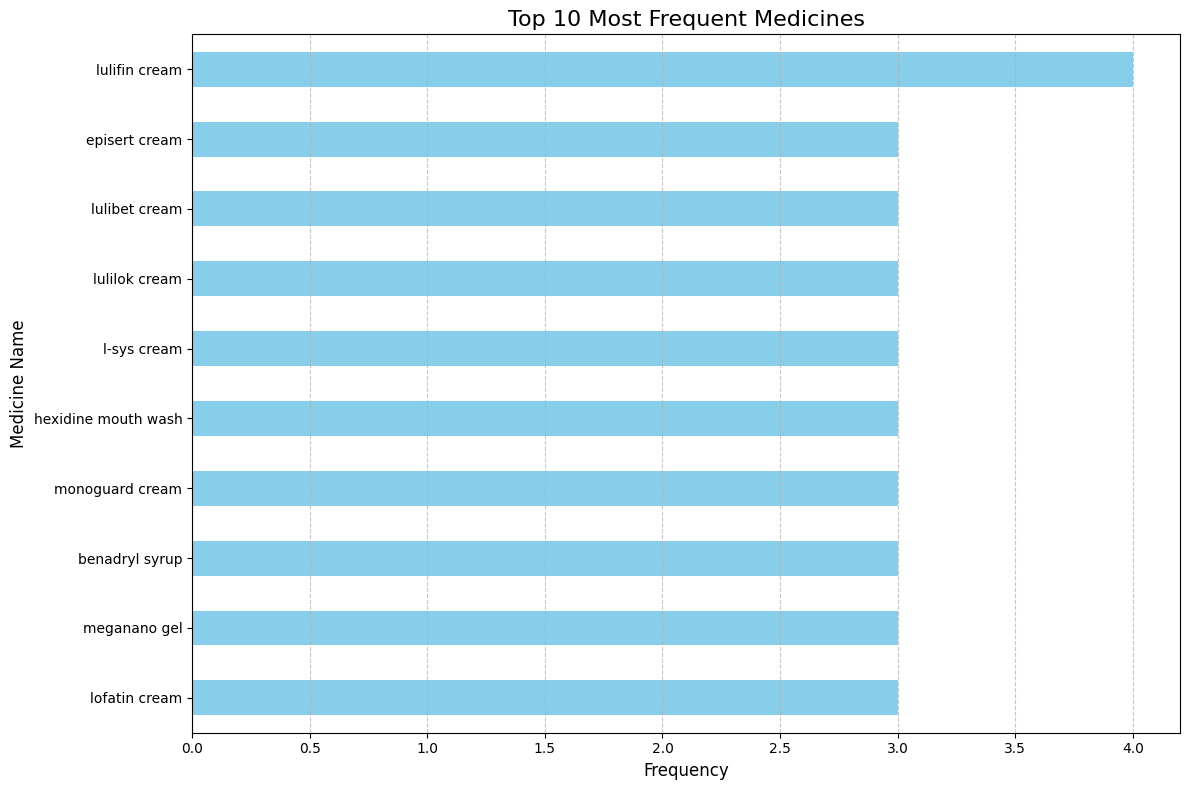

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download stopwords if not already downloaded (uncomment if you haven't run this before)
# nltk.download('stopwords')
# nltk.download('punkt')

# --- Data Loading and Initial Cleaning (from your provided code) ---
df = pd.read_csv('data/medicine_details.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace ('[^a-z0-9_]', '', regex=True)

# Fill missing values for relevant text columns
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert relevant text columns to lowercase and strip whitespace
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

# --- Plotting Highly Recommended (Most Frequent) Medicines ---

if 'medicine_name' in df.columns:
    # Get the top 10 most frequent medicines
    top_10_medicines = df['medicine_name'].value_counts().head(10)

    # Create the plot
    plt.figure(figsize=(12, 8)) # Set figure size for better readability
    top_10_medicines.sort_values(ascending=True).plot(
        kind='barh',
        color='skyblue'
    )
    plt.title('Top 10 Most Frequent Medicines', fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Medicine Name', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for easier reading
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show() # Display the plot
else:
    print("The 'medicine_name' column was not found in the DataFrame. Cannot plot top medicines.")



Age

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for random choices
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download stopwords if not already downloaded (uncomment if you haven't run this before)
# nltk.download('stopwords')
# nltk.download('punkt')

# --- Data Loading and Initial Cleaning (from your provided code) ---
df = pd.read_csv('data/medicine_details.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace ('[^a-z0-9_]', '', regex=True)

# Fill missing values for relevant text columns
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert relevant text columns to lowercase and strip whitespace
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

# --- Simulate Age Group Data (Hypothetical) ---
# IMPORTANT: This 'age_group' column is purely for demonstration purposes
# and is randomly assigned. In a real scenario, this data would come from
# your actual dataset.
if 'age_group' not in df.columns:
    age_groups = ['children', 'adults', 'seniors']
    # Assign age groups randomly, but with a slight bias towards 'adults'
    df['age_group'] = np.random.choice(age_groups, size=len(df), p=[0.2, 0.6, 0.2])
    print("\nSimulated 'age_group' column added for demonstration.")
    print(df['age_group'].value_counts())

# --- Plotting Hypothetical Age-Wise Medicine Usage ---

if 'category' in df.columns and 'age_group' in df.columns:
    # Group by age_group and category, then count occurrences
    age_category_counts = df.groupby(['age_group', 'category']).size().unstack(fill_value=0)

    # Select top N categories to make the plot readable
    # We'll take the top 10 categories overall, then filter for those in the age_category_counts
    top_categories = df['category'].value_counts().head(10).index
    age_category_counts_filtered = age_category_counts[age_category_counts.columns.intersection(top_categories)]

    # Plotting
    plt.figure(figsize=(14, 8))
    age_category_counts_filtered.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')

    plt.title('Hypothetical Medicine Category Usage by Age Group', fontsize=16)
    plt.xlabel('Age Group (Simulated)', fontsize=12)
    plt.ylabel('Number of Medicines', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.legend(title='Medicine Category', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Required columns ('category' or 'age_group') not found for plotting age-wise usage.")




Simulated 'age_group' column added for demonstration.
age_group
adults      6978
children    2404
seniors     2359
Name: count, dtype: int64
Required columns ('category' or 'age_group') not found for plotting age-wise usage.


Top 10 Most used


Top 10 common conditions (from 'uses' column, used as proxy for diseases): ['treatment', 'infections', 'high', 'pain', 'blood', 'hypertension', 'pressure', 'disease', 'heart', 'diabetes']


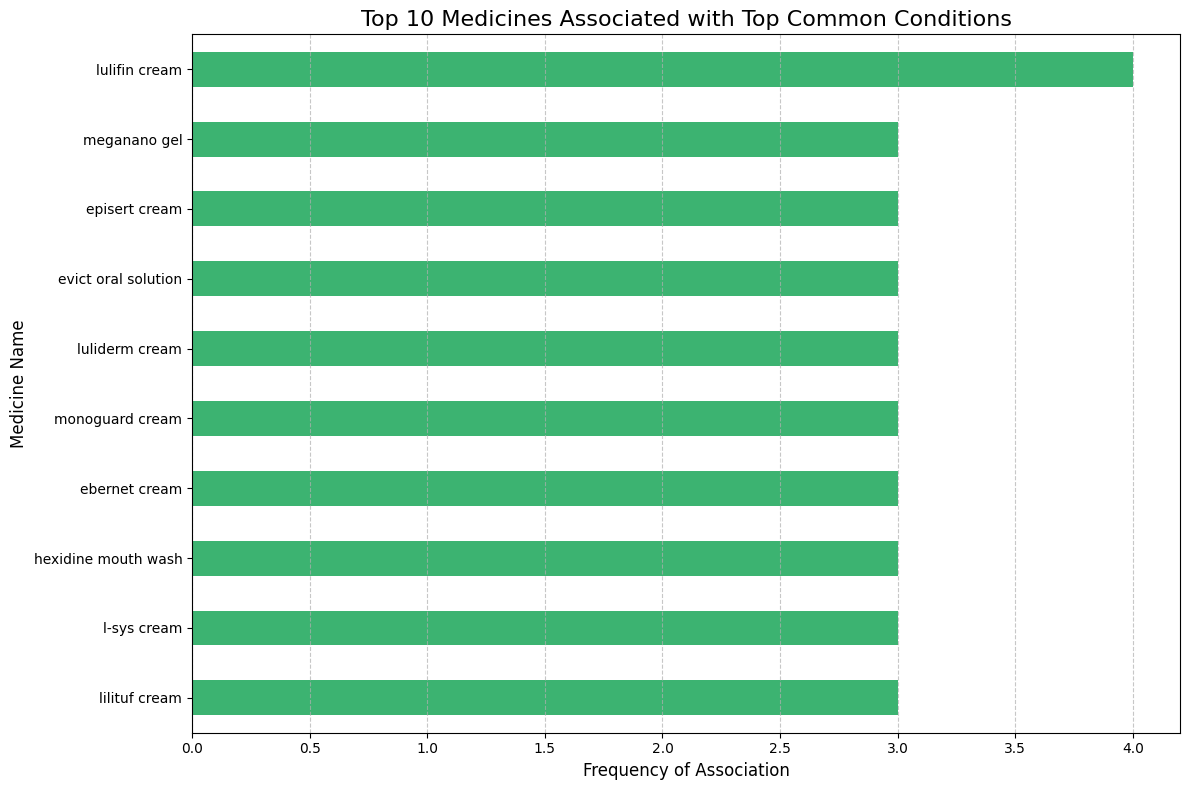

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re # Import regex for more robust text cleaning

# Download stopwords if not already downloaded (uncomment if you haven't run this before)
# nltk.download('stopwords')
# nltk.download('punkt')

# --- Data Loading and Initial Cleaning (from your provided code) ---
df = pd.read_csv('data/medicine_details.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace ('[^a-z0-9_]', '', regex=True)

# Fill missing values for relevant text columns
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert relevant text columns to lowercase and strip whitespace
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

# --- Helper function to analyze text column for common words ---
# This function extracts common words, filtering out stopwords and non-alphabetic characters.
stop_words = set(stopwords.words('english'))

def analyze_text_column(df_col, num_words=20):
    all_words = []
    for text in df_col.astype(str):
        # Use regex to find words, allowing for more specific disease terms if they are hyphenated etc.
        # This regex extracts sequences of letters, and also words with hyphens (e.g., 'anti-inflammatory')
        tokens = re.findall(r'\b[a-z]+(?:-[a-z]+)*\b', text.lower())
        filtered_words = [word for word in tokens if word not in stop_words]
        all_words.extend(filtered_words)
    return Counter(all_words).most_common(num_words)

# --- Identify Top 10 Common "Diseases/Conditions" from 'uses' column ---
# We'll use the most common words in 'uses' as a proxy for common conditions/diseases.
common_uses_words = analyze_text_column(df['uses'], num_words=10)
top_10_conditions = [word for word, count in common_uses_words]

print(f"\nTop 10 common conditions (from 'uses' column, used as proxy for diseases): {top_10_conditions}")

# --- Find Medicines Associated with These Top Conditions ---
# Create a boolean mask to identify rows where the 'uses' column contains any of the top 10 conditions.
# Initialize an empty boolean Series with the same index as the DataFrame.
is_associated_with_top_conditions = pd.Series([False] * len(df), index=df.index)

for condition in top_10_conditions:
    # Use str.contains with regex to ensure whole word matching (e.g., 'cold' matches 'cold' but not 'scold').
    # re.escape is used to escape any special characters in the condition string for regex.
    is_associated_with_top_conditions = is_associated_with_top_conditions | df['uses'].str.contains(r'\b' + re.escape(condition) + r'\b', na=False)

# Filter the DataFrame to include only medicines associated with any of these top conditions.
df_filtered_by_conditions = df[is_associated_with_top_conditions]

# --- Get Top 10 Most Recommended (Frequent) Medicines from the Filtered Set ---
# This identifies the 10 most frequent medicines among those associated with the top conditions.
if not df_filtered_by_conditions.empty and 'medicine_name' in df_filtered_by_conditions.columns:
    top_10_recommended_medicines = df_filtered_by_conditions['medicine_name'].value_counts().head(10)

    # --- Plotting ---
    plt.figure(figsize=(12, 8)) # Set figure size for better readability.
    # Plotting as a horizontal bar chart for better readability of long medicine names.
    top_10_recommended_medicines.sort_values(ascending=True).plot(
        kind='barh',
        color='mediumseagreen' # Using a distinct color for this plot.
    )

    plt.title('Top 10 Medicines Associated with Top Common Conditions', fontsize=16) # Title of the plot.
    plt.xlabel('Frequency of Association', fontsize=12) # Label for the x-axis.
    plt.ylabel('Medicine Name', fontsize=12) # Label for the y-axis.
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for easier reading of values.
    plt.tight_layout() # Adjust layout to prevent labels from overlapping.
    plt.show() # Display the plot.
else:
    print("Could not generate plot. Either no medicines were found associated with the identified top conditions, or the 'medicine_name' column is missing in the filtered DataFrame.")
    if df_filtered_by_conditions.empty:
        print("No medicines were found associated with the identified top conditions after filtering.")



Top 10 most common disease


Top 10 common conditions (from 'uses' column, used as proxy for diseases): ['treatment', 'infections', 'high', 'pain', 'blood', 'hypertension', 'pressure', 'disease', 'heart', 'diabetes']


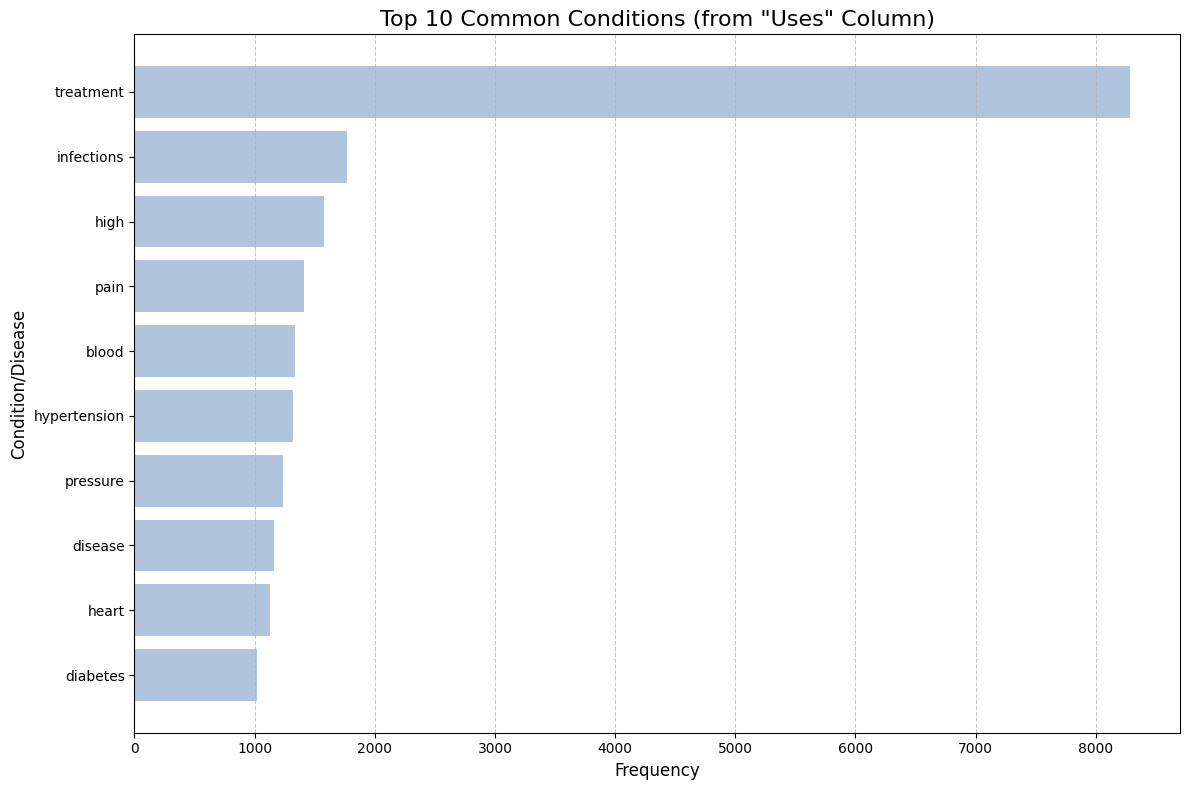

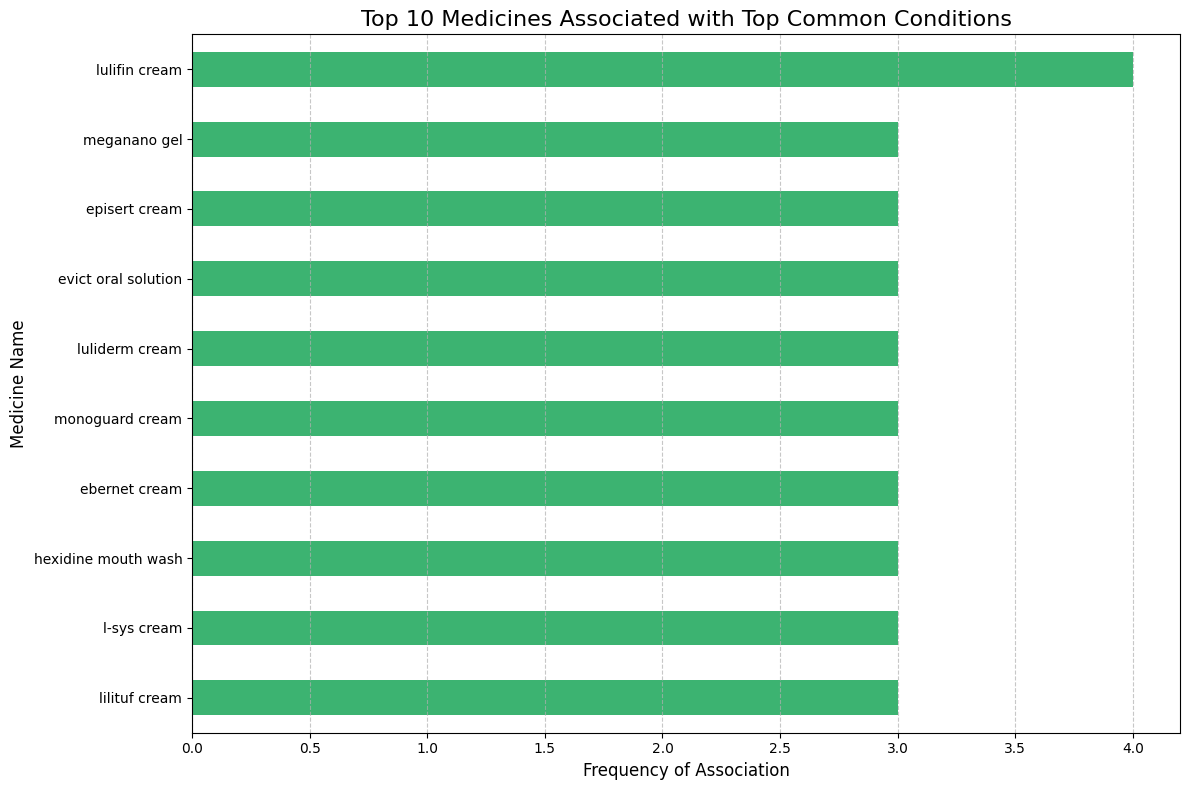

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re # Import regex for more robust text cleaning

# Download stopwords if not already downloaded (uncomment if you haven't run this before)
# nltk.download('stopwords')
# nltk.download('punkt')

# --- Data Loading and Initial Cleaning (from your provided code) ---
df = pd.read_csv('data/medicine_details.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace ('[^a-z0-9_]', '', regex=True)

# Fill missing values for relevant text columns
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert relevant text columns to lowercase and strip whitespace
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

# --- Helper function to analyze text column for common words ---
# This function extracts common words, filtering out stopwords and non-alphabetic characters.
stop_words = set(stopwords.words('english'))

def analyze_text_column(df_col, num_words=20):
    all_words = []
    for text in df_col.astype(str):
        # Use regex to find words, allowing for more specific disease terms if they are hyphenated etc.
        # This regex extracts sequences of letters, and also words with hyphens (e.g., 'anti-inflammatory')
        tokens = re.findall(r'\b[a-z]+(?:-[a-z]+)*\b', text.lower())
        filtered_words = [word for word in tokens if word not in stop_words]
        all_words.extend(filtered_words)
    return Counter(all_words).most_common(num_words)

# --- Identify Top 10 Common "Diseases/Conditions" from 'uses' column ---
# We'll use the most common words in 'uses' as a proxy for common conditions/diseases.
common_uses_words_counts = analyze_text_column(df['uses'], num_words=10)
top_10_conditions = [word for word, count in common_uses_words_counts]
top_10_condition_counts = [count for word, count in common_uses_words_counts]

print(f"\nTop 10 common conditions (from 'uses' column, used as proxy for diseases): {top_10_conditions}")

# --- Plotting Top 10 Common Conditions ---
plt.figure(figsize=(12, 8))
plt.barh(top_10_conditions[::-1], top_10_condition_counts[::-1], color='lightsteelblue') # Reverse for ascending order on plot
plt.title('Top 10 Common Conditions (from "Uses" Column)', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Condition/Disease', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Find Medicines Associated with These Top Conditions ---
# Create a boolean mask to identify rows where the 'uses' column contains any of the top 10 conditions.
# Initialize an empty boolean Series with the same index as the DataFrame.
is_associated_with_top_conditions = pd.Series([False] * len(df), index=df.index)

for condition in top_10_conditions:
    # Use str.contains with regex to ensure whole word matching (e.g., 'cold' matches 'cold' but not 'scold').
    # re.escape is used to escape any special characters in the condition string for regex.
    is_associated_with_top_conditions = is_associated_with_top_conditions | df['uses'].str.contains(r'\b' + re.escape(condition) + r'\b', na=False)

# Filter the DataFrame to include only medicines associated with any of these top conditions.
df_filtered_by_conditions = df[is_associated_with_top_conditions]

# --- Get Top 10 Most Recommended (Frequent) Medicines from the Filtered Set ---
# This identifies the 10 most frequent medicines among those associated with the top conditions.
if not df_filtered_by_conditions.empty and 'medicine_name' in df_filtered_by_conditions.columns:
    top_10_recommended_medicines = df_filtered_by_conditions['medicine_name'].value_counts().head(10)

    # --- Plotting ---
    plt.figure(figsize=(12, 8)) # Set figure size for better readability.
    # Plotting as a horizontal bar chart for better readability of long medicine names.
    top_10_recommended_medicines.sort_values(ascending=True).plot(
        kind='barh',
        color='mediumseagreen' # Using a distinct color for this plot.
    )

    plt.title('Top 10 Medicines Associated with Top Common Conditions', fontsize=16) # Title of the plot.
    plt.xlabel('Frequency of Association', fontsize=12) # Label for the x-axis.
    plt.ylabel('Medicine Name', fontsize=12) # Label for the y-axis.
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for easier reading of values.
    plt.tight_layout() # Adjust layout to prevent labels from overlapping.
    plt.show() # Display the plot.
else:
    print("Could not generate plot. Either no medicines were found associated with the identified top conditions, or the 'medicine_name' column is missing in the filtered DataFrame.")
    if df_filtered_by_conditions.empty:
        print("No medicines were found associated with the identified top conditions after filtering.")



In [30]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re # Import regex for more robust text cleaning
from sklearn.feature_extraction.text import TfidfVectorizer # For TF-IDF
from sklearn.metrics.pairwise import cosine_similarity # For Cosine Similarity
from scipy.sparse import csr_matrix # For sparse matrix representation
from sklearn.neighbors import NearestNeighbors # For KNN

import numpy as np # Import numpy for random choices in simulation

# Download stopwords if not already downloaded (uncomment if you haven't run this before)
# nltk.download('stopwords')
# nltk.download('punkt')

# --- Data Loading and Initial Cleaning ---
df = pd.read_csv('data/medicine_details.csv')

# Standardize column names: remove whitespace, convert to lowercase, replace spaces with underscores, and remove special characters
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace ('[^a-z0-9_]', '', regex=True)

# Fill missing values for relevant text columns with an empty string
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Convert all relevant text columns to string type, convert to lowercase, and strip whitespace
for col in ['uses', 'side_effects', 'composition', 'medicine_name', 'category']:
    if col in df.columns: # Check if column exists before processing
        df[col] = df[col].astype(str).str.lower().str.strip()

# --- Helper function to analyze text column for common words (kept for potential future use or context) ---
stop_words = set(stopwords.words('english'))

def analyze_text_column(df_col, num_words=20):
    all_words = []
    for text in df_col.astype(str):
        # Use regex to find words, allowing for more specific terms if they are hyphenated etc.
        tokens = re.findall(r'\b[a-z]+(?:-[a-z]+)*\b', text.lower())
        filtered_words = [word for word in tokens if word not in stop_words]
        all_words.extend(filtered_words)
    return Counter(all_words).most_common(num_words)

# --- Content-Based Filtering (TF-IDF and Cosine Similarity) ---

# Ensure 'uses' column is available and not empty for TF-IDF
if 'uses' in df.columns and not df['uses'].empty:
    # Initialize TF-IDF Vectorizer
    # TfidfVectorizer converts a collection of raw documents to a matrix of TF-IDF features.
    # max_features limits the number of features (words) to consider, focusing on most important ones.
    # stop_words='english' removes common English stop words (e.g., 'the', 'is', 'a') which don't carry much meaning.
    tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

    # Fit and transform the 'uses' column to create the TF-IDF matrix.
    # This matrix represents the importance of each word in each medicine's 'uses' description.
    tfidf_matrix = tfidf_vectorizer.fit_transform(df['uses'])

    print(f"\nTF-IDF matrix shape: {tfidf_matrix.shape}") # Print the dimensions of the generated TF-IDF matrix.

    # Calculate Cosine Similarity
    # Cosine similarity measures the cosine of the angle between two vectors.
    # In this context, it quantifies the similarity between the TF-IDF vectors of different medicines.
    # A higher cosine similarity (closer to 1) indicates greater similarity between the 'uses' descriptions.
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

    print(f"Cosine similarity matrix shape: {cosine_sim.shape}") # Print the dimensions of the cosine similarity matrix.

    # Create a Series that maps medicine names to their index in the DataFrame.
    # This is crucial for quickly looking up the numerical index of a medicine by its name,
    # which is needed to access its row in the cosine similarity matrix.
    # .drop_duplicates() is used to handle cases where medicine names might appear multiple times
    # and we want a unique mapping to the first occurrence's index.
    indices = pd.Series(df.index, index=df['medicine_name']).drop_duplicates()

    # Function to get content-based recommendations
    # This function takes a medicine name and returns a list of similar medicines
    # based on their 'uses' descriptions and cosine similarity.
    def get_content_based_recommendations(medicine_name, cosine_sim_matrix=cosine_sim, df_data=df, indices_map=indices):
        # Convert the input medicine name to lowercase and strip whitespace for consistent lookup.
        medicine_name = medicine_name.lower().strip()

        # Check if the requested medicine exists in our index map.
        if medicine_name not in indices_map:
            print(f"Medicine '{medicine_name}' not found in the dataset for content-based recommendations.")
            return [] # Return an empty list if the medicine is not found.

        # Get the numerical index of the medicine that matches the given name.
        idx = indices_map[medicine_name]

        # Get the pairwise similarity scores of all medicines with the target medicine.
        # enumerate() adds a counter to an iterable, returning (index, value) pairs.
        sim_scores = list(enumerate(cosine_sim_matrix[idx]))

        # Sort the medicines based on their similarity scores in descending order.
        # The key for sorting is the similarity score (x[1]).
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Get the top 10 most similar medicines.
        # We start from index 1 (sim_scores[1:]) to exclude the medicine itself,
        # as a medicine will always have a similarity score of 1.0 with itself.
        sim_scores = sim_scores[1:11] # Select the next 10 highest scores.

        # Extract the numerical indices of the recommended medicines.
        medicine_indices = [i[0] for i in sim_scores]

        # Return the actual names of the top 10 similar medicines from the DataFrame.
        recommended_medicines = df_data['medicine_name'].iloc[medicine_indices]
        return recommended_medicines.tolist()
else:
    print("The 'uses' column is not available or is empty. Cannot perform content-based filtering.")


# --- Collaborative Filtering (KNN, SVD) - Requires User-Item Interaction Data ---

# --- Simulate User-Item Interaction Data (Hypothetical) ---
# This section creates a dummy dataset for demonstration purposes.
# In a real scenario, you would load this data from your database or file.
print("\n--- Simulating User-Item Interaction Data for Collaborative Filtering ---")

# Let's assume we have 5 users and a subset of your medicines
num_users = 5
# Use a small subset of medicines for simulation to keep the example manageable
num_medicines_for_sim = min(20, len(df['medicine_name'].unique()))
sim_medicine_names = df['medicine_name'].unique().tolist()
if num_medicines_for_sim < len(sim_medicine_names):
    sim_medicine_names = np.random.choice(sim_medicine_names, num_medicines_for_sim, replace=False).tolist()


# Create a list of dictionaries for user-item interactions
# Each interaction represents a user rating a medicine (e.g., on a scale of 1-5)
# Or it could be implicit, like a purchase (represented here as a 'rating' of 1 if purchased)
interaction_data = []
for user_id in range(1, num_users + 1):
    # Each user interacts with a random number of medicines (between 3 and 10)
    num_interactions = np.random.randint(3, min(10, num_medicines_for_sim + 1))
    interacted_medicines = np.random.choice(sim_medicine_names, num_interactions, replace=False)
    for medicine in interacted_medicines:
        # Assign a random rating between 1 and 5
        rating = np.random.randint(1, 6)
        interaction_data.append({'user_id': user_id, 'medicine_name': medicine, 'rating': rating})

# Create a DataFrame from the simulated interaction data
ratings_df = pd.DataFrame(interaction_data)
print("Simulated Ratings DataFrame Head:")
print(ratings_df.head())
print(f"Simulated Ratings DataFrame Shape: {ratings_df.shape}")

# --- Prepare Data for Collaborative Filtering ---
# For KNN, we need a user-item matrix (pivot table)
# Fill NaN values with 0, indicating no interaction/rating
user_medicine_matrix = ratings_df.pivot_table(index='user_id', columns='medicine_name', values='rating').fillna(0)
print("\nUser-Medicine Matrix for KNN (Head):")
print(user_medicine_matrix.head())

# Convert the user-item matrix to a sparse matrix for efficient computation with KNN
user_medicine_sparse_matrix = csr_matrix(user_medicine_matrix.values)

# --- Collaborative Filtering with KNN (Item-Based) ---
print("\n--- Collaborative Filtering with KNN (Item-Based) ---")
# We'll use item-based KNN, finding similar medicines based on how users rated them.
# 'metric' can be 'cosine' or 'euclidean'
# 'algorithm' can be 'brute' (for small datasets) or 'auto'
knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10, n_jobs=-1)
# Fit the model. We transpose the matrix (user_medicine_sparse_matrix.T) because we are doing item-based
# collaborative filtering, meaning we want to find neighbors among items (medicines).
knn_model.fit(user_medicine_sparse_matrix.T)

def get_knn_recommendations(medicine_name, model=knn_model, matrix=user_medicine_sparse_matrix, pivot_table=user_medicine_matrix, num_recommendations=10):
    medicine_name = medicine_name.lower().strip()
    if medicine_name not in pivot_table.columns:
        print(f"Medicine '{medicine_name}' not found in the simulated ratings for KNN recommendations.")
        return []

    # Get the index of the medicine in the pivot table's columns
    medicine_idx = pivot_table.columns.get_loc(medicine_name)

    # Find k-nearest neighbors for the given medicine.
    # We reshape the input to (1, -1) as kneighbors expects a 2D array.
    # n_neighbors is num_recommendations + 1 because the first neighbor will be the medicine itself.
    distances, indices = model.kneighbors(matrix.T[medicine_idx].reshape(1, -1), n_neighbors=num_recommendations + 1)

    # Get the names of the similar medicines (excluding the input medicine itself)
    similar_medicines = []
    # Iterate from 1 to skip the medicine itself (which has a distance of 0 to itself)
    for i in range(1, len(distances.flatten())):
        similar_medicines.append(pivot_table.columns[indices.flatten()[i]])
    return similar_medicines

# Example KNN recommendation
example_medicine_knn = sim_medicine_names[0] if sim_medicine_names else '' # Pick a random medicine from simulated list
if example_medicine_knn:
    knn_recs = get_knn_recommendations(example_medicine_knn)
    if knn_recs:
        print(f"KNN Recommendations for '{example_medicine_knn}':")
        for i, rec_med in enumerate(knn_recs):
            print(f"{i+1}. {rec_med}")
    else:
        print(f"No KNN recommendations found for '{example_medicine_knn}'.")
else:
    print("No simulated medicines available for KNN example.")


# --- Collaborative Filtering with SVD (Singular Value Decomposition) ---
# SVD is a matrix factorization technique used to discover latent factors (hidden features)
# that explain user-item interactions.
print("\n--- Collaborative Filtering with SVD ---")







TF-IDF matrix shape: (11741, 698)
Cosine similarity matrix shape: (11741, 11741)

--- Simulating User-Item Interaction Data for Collaborative Filtering ---
Simulated Ratings DataFrame Head:
   user_id           medicine_name  rating
0        1       xoxe 250mg tablet       5
1        1  ranozest 500 sr tablet       5
2        1        nebicip 5 tablet       1
3        1       klm-d3 nano drops       2
4        1          urifree tablet       4
Simulated Ratings DataFrame Shape: (34, 3)

User-Medicine Matrix for KNN (Head):
medicine_name  alcoxia-mr tablet  azulix 1 tablet  dablexa 150 capsule  \
user_id                                                                  
1                            5.0              0.0                  0.0   
2                            2.0              0.0                  2.0   
3                            0.0              0.0                  2.0   
4                            0.0              0.0                  0.0   
5                         